In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
clean_data = pd.read_parquet("../cleaned_data/clean_yellow_tripdata_2026-01.parquet")

In [22]:
df = clean_data.copy()

In [23]:
df.shape

(1773721, 38)

In [24]:
df['extra_amount'].info()

<class 'pandas.Series'>
RangeIndex: 1773721 entries, 0 to 1773720
Series name: extra_amount
Non-Null Count    Dtype  
--------------    -----  
1773721 non-null  float32
dtypes: float32(1)
memory usage: 6.8 MB


In [25]:
df['extra_amount'].describe()

count    1.773721e+06
mean     1.564195e+00
std      1.949254e+00
min      0.000000e+00
25%      0.000000e+00
50%      1.000000e+00
75%      2.500000e+00
max      1.746000e+01
Name: extra_amount, dtype: float64

# extra_amount

In [26]:
df['extra_amount'].isna().sum()

np.int64(0)

In [27]:
df['extra_amount'].describe()

count    1.773721e+06
mean     1.564195e+00
std      1.949254e+00
min      0.000000e+00
25%      0.000000e+00
50%      1.000000e+00
75%      2.500000e+00
max      1.746000e+01
Name: extra_amount, dtype: float64

In [28]:
df['extra_amount'].quantile([0.9,0.99,0.995,0.999,0.9995,0.9999])

0.9000     4.25
0.9900     7.50
0.9950    10.00
0.9990    11.00
0.9995    12.50
0.9999    12.50
Name: extra_amount, dtype: float64

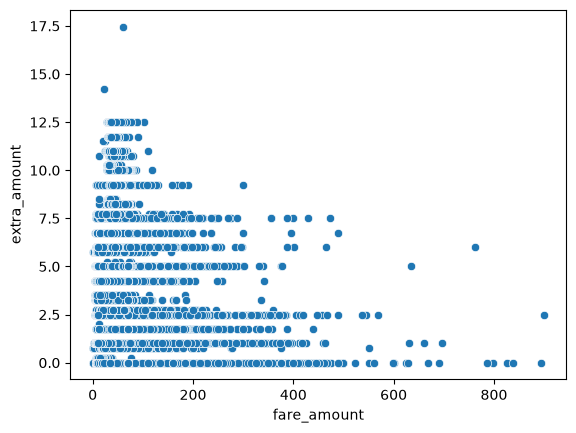

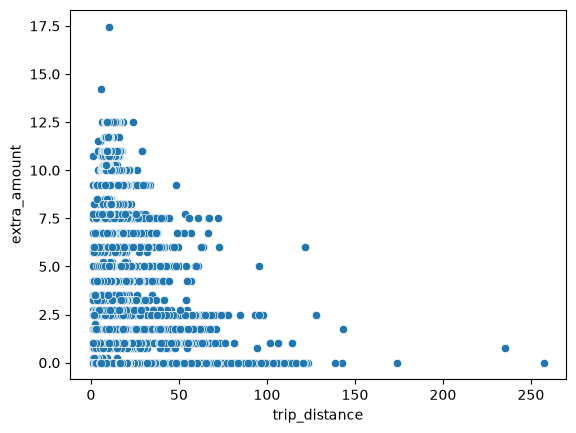

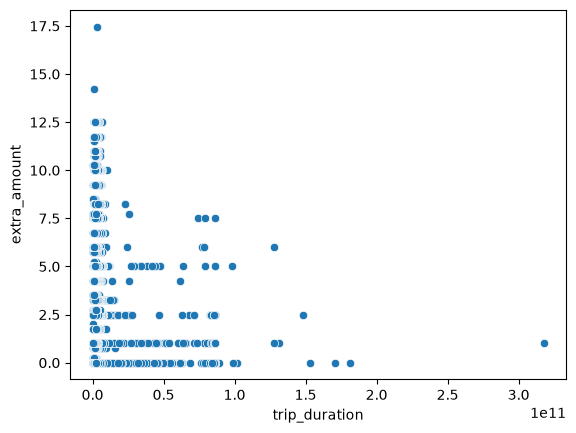

In [29]:
sns.scatterplot(
    x = df['fare_amount'],
    y = df['extra_amount']
)
plt.show()
sns.scatterplot(
    x = df['trip_distance'],
    y = df['extra_amount']
)
plt.show()
sns.scatterplot(
    x = df['trip_duration'],
    y = df['extra_amount']
)
plt.show()

<Axes: xlabel='fare_type_id'>

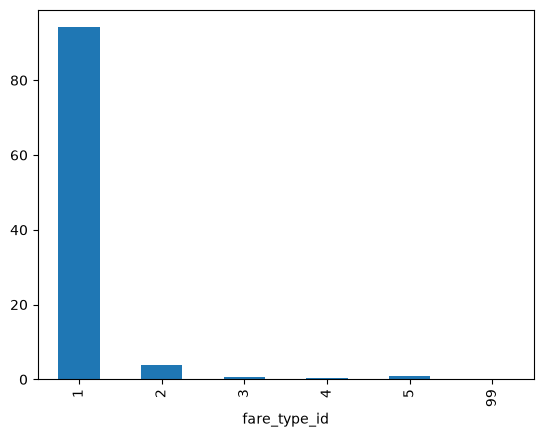

In [30]:
grouped = df.groupby('fare_type_id')['extra_amount'].sum()
percentage = (grouped / grouped.sum()) * 100
percentage.plot(kind = 'bar')


In [31]:
print(df.groupby('fare_type_id')['extra_amount']
      .apply(lambda x: (x > 0).sum()))


positive_fraction = (
    df.groupby('fare_type_id')['extra_amount']
      .apply(lambda x: (x > 0).mean())
)

positive_fraction


fare_type_id
1     976326
2      21422
3       5031
4       4911
5       5176
99         3
Name: extra_amount, dtype: int64


fare_type_id
1     0.620404
2     0.292638
3     0.620422
4     0.652105
5     0.413089
99    0.000030
Name: extra_amount, dtype: float64

In [32]:
print(df.groupby('fare_type_id')['extra_amount'].mean())
df.groupby('fare_type_id')['extra_amount'].median()

fare_type_id
1     1.659733
2     1.477289
3     2.390584
4     1.650544
5     1.800798
99    0.000122
Name: extra_amount, dtype: float32


fare_type_id
1     1.0
2     0.0
3     1.0
4     1.0
5     0.0
99    0.0
Name: extra_amount, dtype: float32

In [33]:
grouped = df.groupby('payment_type')['extra_amount'].sum()
percentage = (grouped / grouped.sum()) * 100
percentage

payment_type
1    88.529587
2    10.013798
3     0.484863
4     0.971753
Name: extra_amount, dtype: float32

In [34]:
positive_fraction = (
    df.groupby('payment_type')['extra_amount']
      .apply(lambda x: (x > 0).mean())
)

positive_fraction


payment_type
1    0.572632
2    0.550607
3    0.788458
4    0.595067
Name: extra_amount, dtype: float64

In [35]:
print(df.groupby('payment_type')['extra_amount'].mean())
df.groupby('payment_type')['extra_amount'].median()

payment_type
1    1.577631
2    1.430102
3    2.733642
4    1.528821
Name: extra_amount, dtype: float32


payment_type
1    1.00
2    1.00
3    3.25
4    1.00
Name: extra_amount, dtype: float32

# change data type to float 32

In [36]:
df['extra_amount'] = df['extra_amount'].astype('float16')

In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1773721 entries, 0 to 1773720
Data columns (total 38 columns):
 #   Column                        Dtype          
---  ------                        -----          
 0   vendor_id                     int8           
 1   pickup_datetime               datetime64[us] 
 2   dropoff_datetime              datetime64[us] 
 3   passenger_count               int8           
 4   trip_distance                 float32        
 5   fare_type_id                  int8           
 6   store_and_fwd_flag            boolean        
 7   pickup_location_id            int16          
 8   dropoff_location_id           int16          
 9   payment_type                  int8           
 10  fare_amount                   float32        
 11  extra_amount                  float16        
 12  mta_tax_amount                float64        
 13  tip_amount                    float64        
 14  tolls_amount                  float64        
 15  improvement_surcharge_amou

# save back to clean data

In [38]:
df.to_parquet('../cleaned_data/clean_yellow_tripdata_2026-01.parquet', index=False)